## init

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set all fonts to Arial size 7
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

In [3]:
from autoadsorbate import Surface
from ase.io import read, write
from ase.visualize import view
import numpy as np
from ase import Atoms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.ticker import FixedLocator


from cft import Manifold
from autoadsorbate.Particle import get_cube_surface_pts, grid_round_cube
from cft.mesh_utils import compute_outward_vertex_normals_quads

from ase.io import read, write
from ase.visualize import view
from autoadsorbate import Fragment
from autoadsorbate.Surf import attach_fragment
from ase.constraints import FixAtoms
import copy

In [4]:
from mace.calculators import mace_mp
clean_calc = mace_mp(model=
                # '/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model',
                '/mnt/c/Users/ef/Desktop/tmp/mace-omat-0-medium.model',
                device='cpu',
                )

/home/ef/venvs/mace_env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/ef/venvs/mace_env/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head default out of ['default']
Default dtype float32 does not match model dtype float64, converting models to float32.


## manifold

In [ ]:
cats = [
    'C1CN2CCN1CC2',
    'CN1CCCC1',
    'c1ccccc1CN2CCC2',
    'c1ccccc1COC2CCN(C)C2',
    'c1ccccc1COCCN2CCCC2'
]

cats_traj = []
for c in cats:
    f = Fragment(
        c, to_initialize=1000,
        prune_rms_thresh = 0.5, # same as in rdkit, small numb = more conformers
        )
    cats_traj += [f.get_conformer(i) for i, _ in enumerate(f.conformers)]

# view(cats_traj)

User requested to_initialize = 1000 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1000 conformers.
After pruning with 0.5; len(conformer_trj) = 4 unique conformers are found.
User requested to_initialize = 1000 conformers.
After pruning with 0.5; len(conformer_trj) = 5 unique conformers are found.
User requested to_initialize = 1000 conformers.
After pruning with 0.5; len(conformer_trj) = 38 unique conformers are found.
User requested to_initialize = 1000 conformers.
After pruning with 0.5; len(conformer_trj) = 122 unique conformers are found.


In [25]:
m = Manifold(cats_traj[-1], mode='particle', precision=1, touch_sphere_size =2.1)


In [ ]:
m.run_probe_scan(probes=[Fragment('ClC', to_initialize=1)])

User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.


Scanning probe positions: 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]

energies.shape = (8, 1)


In [9]:
cats_traj = read('cats_traj.xyz', index=':')
out_traj = read('out_trj.xyz', index=':')

In [13]:
view([a + out_traj[i] for i, a in enumerate(cats_traj)])

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [10]:
view(cats_traj)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [63]:
yields = {
    'C1CN2CCN1CC2': 36,
    'CN1CCCC1': 34,
    'c1ccccc1CN2CCC2': 32,
    'c1ccccc1COC2CCN(C)C2': 7,
    'c1ccccc1COCCN2CCCC2': 1
}

vals = []

for i, a in enumerate(out_traj):
    vals += list(a.arrays['e_ClC_0'])

min = np.min(vals)
max = min+.7


df = []
for i, a in enumerate(out_traj):

    active_area = np.sum((a.arrays['e_ClC_0'] < max)  * a.arrays['area'])
    info = cats_traj[i].info
    info['active_area'] = active_area
    total_area = np.sum(a.arrays['area'])
    info['total_area'] = total_area
    df.append(info)

df = pd.DataFrame(df)
df['yield'] = [yields[smi] for smi in df.smiles.values]
df['active_area_rel'] = df['active_area']  / df['total_area']

df

,smiles,conf_i,active_area,total_area,yield,active_area_rel
0,C1CN2CCN1CC2,0,3.781695,220.438619,36,0.017155
1,CN1CCCC1,0,1.744081,205.711293,34,0.008478
2,c1ccccc1CN2CCC2,0,0.165420,287.406551,32,0.000576
3,c1ccccc1COC2CCN(C)C2,0,1.275122,350.037439,7,0.003643
4,c1ccccc1COC2CCN(C)C2,1,1.674537,347.226706,7,0.004823
5,c1ccccc1COC2CCN(C)C2,2,1.291033,347.628910,7,0.003714
6,c1ccccc1COC2CCN(C)C2,3,1.221846,350.046611,7,0.003491
7,c1ccccc1COC2CCN(C)C2,4,1.038266,347.556856,7,0.002987
8,c1ccccc1COC2CCN(C)C2,5,1.032193,338.950381,7,0.003045
9,c1ccccc1COC2CCN(C)C2,6,1.598227,343.769521,7,0.004649


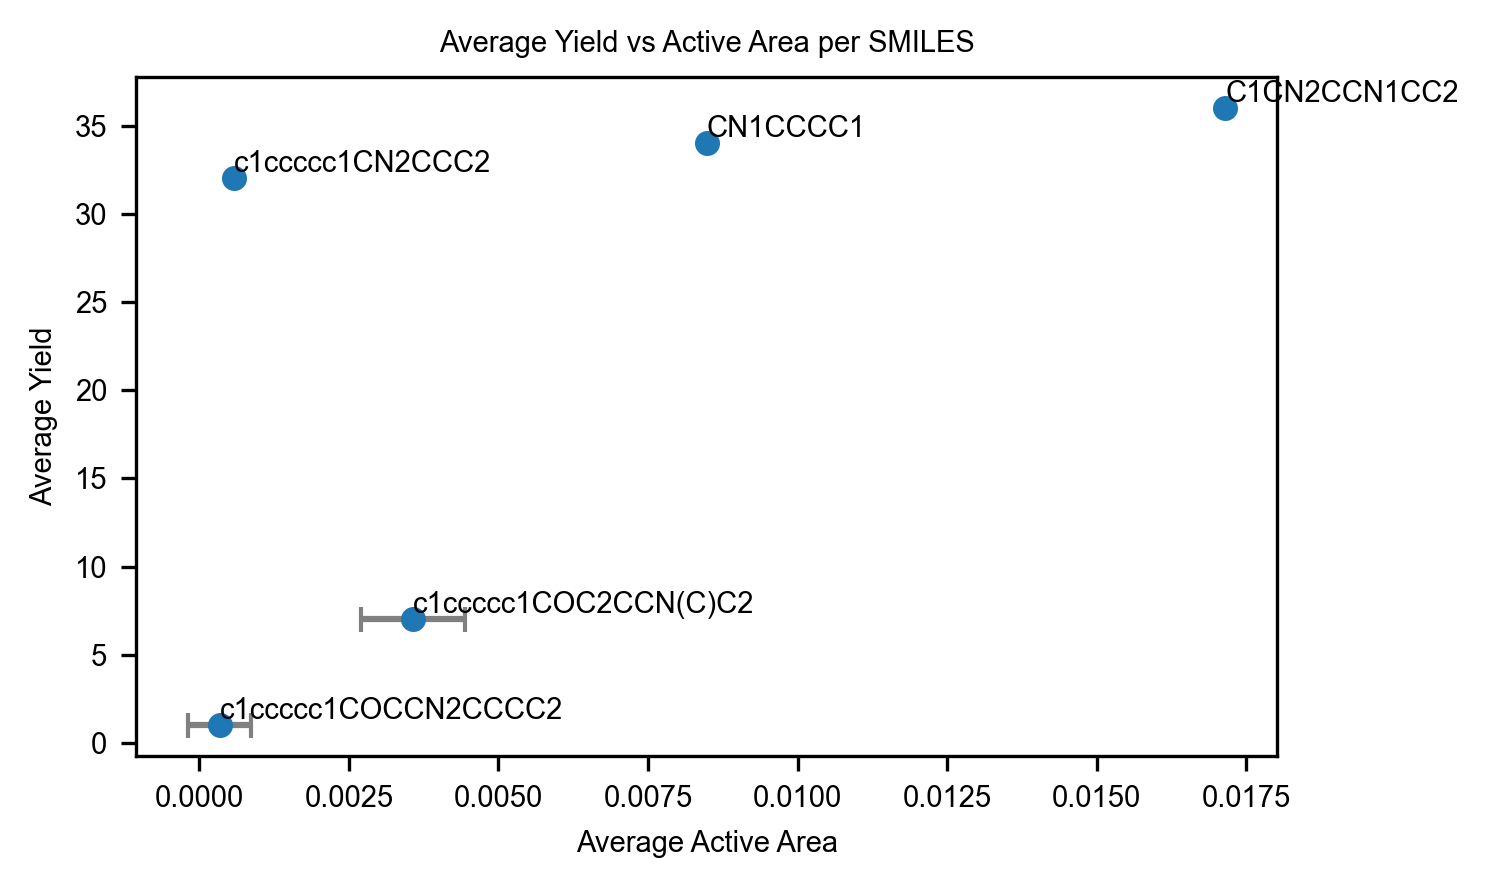

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by smiles and compute mean and std
grouped = df.groupby("smiles")[["active_area_rel", "yield"]].agg(["mean", "std"])
grouped.columns = ["active_area_mean", "active_area_std", "yield_mean", "yield_std"]
avg_df = grouped.reset_index()

# Plot
plt.figure(figsize=(5, 3), dpi=300)
plt.errorbar(
    avg_df["active_area_mean"],
    avg_df["yield_mean"],
    xerr=avg_df["active_area_std"],
    yerr=avg_df["yield_std"],
    fmt="o",
    ecolor="gray",
    capsize=3,
    markersize=5,
)

# Add SMILES labels
for _, row in avg_df.iterrows():
    plt.text(
        row["active_area_mean"], row["yield_mean"],
        row["smiles"], fontsize=7, ha="left", va="bottom"
    )

plt.xlabel("Average Active Area")
plt.ylabel("Average Yield")
plt.title("Average Yield vs Active Area per SMILES")
plt.tight_layout()
plt.show()


<Axes: ylabel='Count'>

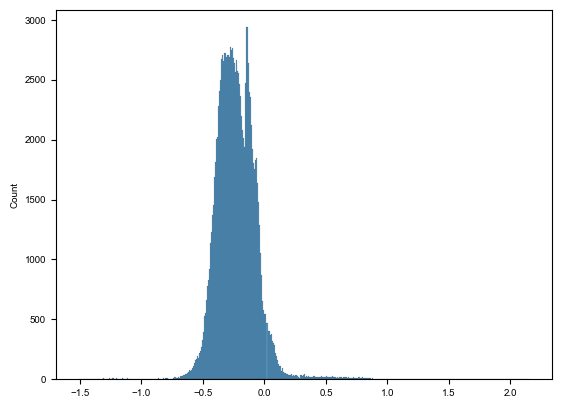

In [40]:
sns.histplot(vals)

In [33]:
df

,smiles,conf_i,yield
0,C1CN2CCN1CC2,0,36
1,CN1CCCC1,0,34
2,c1ccccc1CN2CCC2,0,32
3,c1ccccc1COC2CCN(C)C2,0,7
4,c1ccccc1COCCN2CCCC2,0,1


In [18]:
f = Fragment(r'O=C(N[C@@H](C(C)(C)C)C(N[C@@H](C/[N+](C1([O-])COC(=O)CO1)=C(N(C)C)\N(C)C)C(N(C)C)=O)=O)NC1=CC=C(Cl)C=C1', to_initialize=100)

User requested to_initialize = 100 conformers.
After pruning with 0.5; len(conformer_trj) = 97 unique conformers are found.


In [19]:
view(f.conformers)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [27]:

f = Fragment('ClC1([O-])COC(=O)CO1', to_initialize=100)
view([f.get_conformer(i) for i, _ in enumerate(f.conformers)])

User requested to_initialize = 100 conformers.
After pruning with 0.5; len(conformer_trj) = 10 unique conformers are found.


<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [21]:
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [22]:
def estimate_normals_o3d(points, k=10):
    pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(points))
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamKNN(knn=k))
    pcd.orient_normals_consistent_tangent_plane(k)
    normals = np.asarray(pcd.normals)
    return normals

In [23]:
estimate_normals_o3d(f.get_conformer(0).positions)

array([[ 0.62074312,  0.70755657,  0.33770059],
       [ 0.33555679,  0.79751229,  0.5013739 ],
       [-0.38570068, -0.00740459,  0.92259425],
       [-0.18461346, -0.25317076,  0.94964332],
       [-0.87492808,  0.47834672,  0.07540067],
       [-0.63625792,  0.37332114,  0.67513494],
       [-0.11134155,  0.08985775,  0.98971139],
       [-0.32569303, -0.93770403, -0.12097603],
       [ 0.28890126, -0.92362758,  0.25188919],
       [ 0.72915041, -0.68296466, -0.0435769 ],
       [ 0.82090441, -0.08805434, -0.56423611],
       [ 0.36602807,  0.93015615,  0.02886154],
       [ 0.2029978 ,  0.86945628, -0.45037504],
       [ 0.94137656,  0.3200693 , -0.10661054],
       [ 0.90282788,  0.0929485 , -0.41983615],
       [ 0.94938776,  0.04892437, -0.31027294],
       [ 0.9417278 , -0.03553863, -0.33449327],
       [ 0.97374081,  0.14382611, -0.17647347],
       [ 0.97374081,  0.14382611, -0.17647347],
       [ 0.88192377,  0.05740126, -0.46788413],
       [ 0.44366924,  0.84721255, -0.292